# Inventory Generation with Probabilistic Housing Units

This example demonstrates the **complete, end-to-end workflow** for generating a building
inventory enriched with household-level demographic data.

**Goal:**
Starting from a simple location name (e.g., "Tiburon, CA"), we will:
1.  Build a geometric inventory of building footprints.
2.  Enrich it with physical attributes (e.g., year built, stories).
3.  Populate residential buildings with probabilistic households (income, race, size)
    statistically matched to the local US Census demographics.

**Scope & Limitations:**
- **USA Only:** This workflow relies on US-specific datasets (NSI, US Census).
  It is not robust for international locations.
- **Service Stability:** Public data APIs (NSI, Overture, Census) occasionally experience
  downtime. If you encounter connection errors, please wait a few minutes and try again.
- **Not Hazus-Ready:** While rich, this inventory is not yet formatted for a full
  Hazus damage assessment. For Hazus-specific inferencing, please see the scripts
  in `examples/inventory_creation`.

**Flexibility:**
While this script builds an inventory from scratch using BRAILS tools, you can bring
your own! If you already have a GeoJSON building inventory with the required columns
(Occupancy, PlanArea, Stories), you can simply load it using `AssetInventory.read_from_geojson()`
and skip directly to **Step 6** to generate households.

## Description of Program
- program:    ncoda_07iv1_SimCenter_HUA
- task:       Demonstration of using pyncoda with NHERI-SimCenter BRAILS++
- See github commits for description of program updates
- Current Version: v1 - 
- 2025-12-03  Version created by (Adam Zsarnoczay)[https://github.com/zsarnoczay]
- project:    NHERI-SimCenter
- funding:	  NSF
- author:     Adam Zsarnoczay

## Required Citations:
For BRAILS++

Barbaros Cetiner, Frank McKenna, Sang-ri Yi, Brian Wang, and Ioannis Vouvakis Manousakis. (2025). BRAILS++: Version v4.1.3. Zenodo. DOI: 10.5281/zenodo.16910168

Adam Zsarnóczay, Gregory G. Deierlein, Frank McKenna, Matthew Schoettler, Sang-Ri Yi, Barbaros Cetiner, Aakash Bangalore Satish, Jinyan Zhao, Justin Bonus, Abiy F. Melaku, Sina Naeimi, Pedro Arduino, Rachel Davidson, Catherine Gorle, Sanjay Govindjee, Ahsan Kareem, Tracy L. Kijewski-Correa, Laura N. Lowes, Michael Motley, Seymour M. J. Spence, Ertugrul Taciroglu, Alexandros A. Taflanidis, and Matthew DeJong (2025) An open-source simulation platform to support and foster research collaboration in natural hazards engineering. Frontiers in Built Environment. Volume 11 - 2025. DOI: 10.3389/fbuil.2025.1590479

For use of pyncoda and the Housing Unit Allocation Methodology
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

## Setup Python
pip install brails

In [ ]:
from brails.types import RegionBoundary
from brails.scrapers import OvertureMapsFootprintScraper
from brails.scrapers import NSI_Parser
from brails.aggregators import BasicPointsToPolygonsAllocator
from brails.imputers import KnnImputer
from brails.aggregators import PyncodaHousingUnitAllocator

from pathlib import Path

## 1. Define the Region of Interest

First, we define the geographic area for our analysis.
The `RegionBoundary` class allows you to specify a region by its name (e.g., "Berkeley, CA")
or by a bounding box coordinate tuple.

**Options:**
- To use a specific bounding box, change `type` to `'locationPolygon'` and provide
  a tuple of `(min_longitude, min_latitude, max_longitude, max_latitude)` as `data`.


Searching for Seaside, OR...
Found Seaside, Clatsop County, Oregon, United States


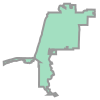

In [2]:
region_boundary_object = RegionBoundary(
    {
        "type": "locationName",
        "data": "Seaside, OR"
    }
)

geometry, description, osm_id = region_boundary_object.get_boundary()
display(geometry)

## 2. Download Building Footprints (Geometry)

We fetch the physical shapes of **building footprints** (polygons) from Overture Maps.
Overture Maps combines data from open sources (OpenStreetMap) and commercial donors
(Microsoft, Google, Meta) to provide high-quality building footprints.

**Why we do this:**
We strictly use this for the *geometry* of the buildings. We remove all other
metadata to demonstrate how to build a rich inventory from scratch using
just these raw shapes.

**Alternative Providers:**
There is no single "best" footprint provider for every location. Depending on the
region, one source may be more complete or recent than another. We recommend
inspecting the results from different providers:
- `OSM_FootprintScraper`: Fetches data from OpenStreetMap.
- `USA_FootprintScraper`: Fetches data from the **FEMA USA Structures** database.

In [3]:
bldg_inventory = OvertureMapsFootprintScraper({'length': 'ft'}).get_footprints(region_boundary_object)

# only use the footprint geometry and remove all other metadata for clarity
bldg_inventory.remove_features(bldg_inventory.get_all_asset_features())

No weight unit specified. Using default: 'lb'.
'overtureRelease' not defined in input. Falling back to latest release: 2025-10-22.0

Searching for Seaside, OR...
Found Seaside, Clatsop County, Oregon, United States


Reading dataset batches: 258it [00:22, 11.46it/s]
Reading dataset batches: 12it [00:02,  4.57it/s]



Finding the assets within the specified area...

Found a total of 4679 assets within the specified area.


True

## 3. Download Building Attributes (Data)

Next, we fetch detailed building attributes from the **National Structure Inventory (NSI)**.
NSI is a US Army Corps of Engineers dataset designed for hazard modeling (e.g., flood damage).
It integrates data from tax assessors, CoreLogic, and Census demographics.

**Important Caveats:**
- **Point Data:** NSI data is point-based, meaning each building is represented by a single
  coordinate, not a shape.
- **Inferred Data:** Many attributes (like foundation type or number of stories) are
  often **imputed or inferred** based on regional averages rather than direct observation.
  It is a statistical model, not ground truth.

**Feature Selection:**
We map NSI attributes to standard SimCenter naming conventions:
- `found_type` -> `FoundationType`: (e.g., Slab, Crawlspace) Critical for flood vulnerability.
- `found_ht` -> `FirstFloorElevation`: Height of the first floor above ground.
- `sqft` -> `PlanArea`: The footprint area (often derived from tax records).
- `num_story` -> `NumberOfStories`: Inferred from height or tax data.
- `occtype` -> `OccupancyClass`: (e.g., RES1, COM1) The primary use of the building.
- `pop2*` -> `Population`: Estimated day/night occupancy based on Census blocks.
- `med_yr_blt` -> `YearBuilt`: Median year built for the area.
- `students` -> `StudentPopulation`: Estimated student counts for schools.
- `bldgtype` -> `BuildingType`: (e.g., Wood, Masonry) Structural material type.

In [4]:
nsi_points = NSI_Parser().get_raw_data(region_boundary_object)

# Rename the features we need later using standard SimCenter labels
feature_rename_map = {
    'fd_id': 'fd_id',
    'type': 'type',
    'bldgtype': 'BuildingType',
    'found_type': 'FoundationType',
    'found_ht': 'FirstFloorElevation',
    'pop2amu65': 'NightPopulationUnder65',
    'pop2amo65': 'NightPopulationOver65',
    'pop2pmu65': 'DayPopulationUnder65',
    'pop2pmo65': 'DayPopulationOver65',
    'x': 'Longitude',
    'y': 'Latitude',
    'sqft': 'PlanArea',
    'num_story': 'NumberOfStories',
    'students': 'StudentPopulation',
    'med_yr_blt': 'YearBuilt',
    'occtype': 'OccupancyClass'
}
nsi_points.change_feature_names(feature_rename_map)

# remove all other features for clarity
features_to_remove = nsi_points.get_all_asset_features()
features_to_remove.difference_update(feature_rename_map.values())
nsi_points.remove_features(features_to_remove)


Searching for Seaside, OR...
Found Seaside, Clatsop County, Oregon, United States


INFO:root:
Getting National Structure Inventory (NSI) building data for the entered location...



Found a total of 4134 building points in NSI that are within the entered region of interest


True

## 4. Merge Attributes with Geometry

We now have two datasets:
1. **Polygons** (Shapes) from Overture Maps.
2. **Points** (Data) from NSI.

The `BasicPointsToPolygonsAllocator` spatially joins these sets. It assigns the attributes
from an NSI point to the Overture footprint that contains it.

**How it Works:**
1. **Strict Inclusion:** By default, a point must fall strictly inside a polygon.
2. **Convex Hull (`use_convex_hull=True`):** Complex building shapes (like U-shapes)
   can cause valid centroids to fall "outside" the polygon. We use the convex hull
   (the "shrink wrap" shape) to capture these points.
3. **Buffer (`buffer_dist=10.0`):** We add a **10-meter** tolerance buffer to catch points that
   might be slightly offset due to GPS errors or different data vintages.

**Caveat:**
This is a strict spatial join. NSI points that do not land within a footprint (even
with the buffer) will be **dropped**. Conversely, footprints that contain no NSI points
will remain in the inventory but will have no attribute data (missing features).

In [5]:
BasicPointsToPolygonsAllocator(
    polygon_inventory=bldg_inventory,
    point_inventory=nsi_points,
).allocate(
    use_convex_hull = True,
    buffer_dist = 10.0
)

Allocated point features to 3482 polygons.


## 5. Impute Missing Data

After the merge, our inventory is incomplete. Some footprints had no matching NSI point,
leaving them with missing attributes (NaN). Even successfully matched buildings might
have gaps in the original NSI data.

The `KnnImputer` fills these gaps using a **K-Nearest Neighbors** approach. It assumes that
nearby buildings are likely to be similar (e.g., neighbors often have similar
year-built dates or story counts).

**Key Options:**
- `n_possible_worlds`: How many different imputed "versions" of the inventory to generate.
  We use `1` for a single deterministic best-guess.
- `exclude_features`: Lists columns (like `Latitude`, `Longitude`, `id`) that should *not*
  be imputed because they are unique or spatial constants.
- `k_nn`: The number of neighbors to consider (default is 5).
- `create_correlation`: When True, imputation is performed sequentially in batches.
  The first batch of imputed buildings becomes part of the "truth" for the next batch,
  ensuring that neighborhoods develop consistent, spatially correlated characteristics
  rather than random noise.

In [6]:
bldg_inventory_imputed = KnnImputer(
    bldg_inventory,
    n_possible_worlds=1,
    exclude_features=['Latitude','Longitude','fd_id','id']
).impute()

Existing worlds: 1
New worlds per existing world: 1
world # 0
The feature id does not exist in inventory. Ignoring it from the exclude list.
Missing percentages among 4679 assets
BuildingType: 25.58%
FoundationType: 25.58%
FirstFloorElevation: 25.58%
NightPopulationUnder65: 25.58%
NightPopulationOver65: 25.58%
DayPopulationUnder65: 25.58%
DayPopulationOver65: 25.58%
PlanArea: 25.58%
NumberOfStories: 25.58%
StudentPopulation: 25.58%
YearBuilt: 25.58%
OccupancyClass: 25.58%
Primitive imputation done.
Running the main imputation. This may take a while.
Done imputation. It took 0.01 mins


## 6. Generate Probabilistic Households

This step populates residential buildings with probabilistic households.
The `PyncodaHousingUnitAllocator` acts as a bridge to the **`pyncoda`** library.

**What does `pyncoda` do?**
It downloads US Census demographic data and generates a probabilistic population
that statistically matches the local census block. It then assigns those households
to the residential buildings in our inventory.

**Configuration:**
- `vintage`: Which Census year to use ('2010' or '2020').
- `key_features`: Tells `pyncoda` which columns in *our* inventory correspond to the
  building traits it needs (Occupancy, Area, Stories) to make intelligent assignments.
- `seed`: Ensures the random generation is reproducible.
- `clean_work_dir`: When `True`, creates a fresh working environment. Set to `False`
  to reuse downloaded Census data for faster re-runs on the same location.

Initial number of buildings loaded: 4679
------------------------------
Number of buildings with all required features present: 4679
------------------------------
Number of buildings remaining after filtering: 4137


INFO:pyogrio._io:Created 4,137 records


Starting job. Total points to process: 4137

Processing new tract. Points remaining: 4137
  Picking point: (45.97236891958582, -123.92558081264772)
  API Call success. Caching new GEOID: 41007951100
  Local search found 896 points inside this tract.

Processing new tract. Points remaining: 3241
  Picking point: (45.98313405, -123.92443139999999)
  API Call success. Caching new GEOID: 41007950900
  Local search found 3165 points inside this tract.

Processing new tract. Points remaining: 76
  Picking point: (46.010658, -123.909787)
  API Call success. Caching new GEOID: 41007950700
  Local search found 76 points inside this tract.

--- Job Finished ---
Total points successfully processed: 4137
Total points remaining (unprocessed): 0
Total unique API calls made: 3
Creating folder c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda_working_dir\pyncoda_working_dir/BRAILSCommunity to store output.
Creating folder c:\Users\nathanael99\MyProjects\GitHub\intersect-community

INFO:pyogrio._io:Created 4,137 records


Generate Address point inventory for: BRAILS Community
Based on building inventory: filtered NSI
Generate Address point inventory for: BRAILS Community
Based on building inventory: filtered NSI
***************
Address Point Inventory Workflow
***************

Generating Address Point Inventory v2.0.0 data for BRAILS Community 2020
***************
Obtaining Census Block, Place, and PUMA Data
***************

Clatsop County, OR : county FIPS Code 41007
State Name OREGON matches State FIPS Code 41
Checking if file exists: c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda_working_dir\pyncoda_working_dir/BRAILSCommunity/01_CommunitySourceData/tl_2020_41007_tabblockplacepuma20EPSG4269.csv
Creating block data for  41007
Original Census block data URL: https://www2.census.gov/geo/tiger/TIGER2020PL/STATE/41_OREGON/41007/tl_2020_41007_tabblock20.zip


...

Original Census place data URL: https://www2.census.gov/geo/tiger/TIGER2020/PLACE/tl_2020_41_place.zip


c:\Users\nathanael99\AppData\Local\miniconda3\envs\pyncoda20251203\lib\site-packages\urllib3\connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www2.census.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Original Census puma data URL: https://www2.census.gov/geo/tiger/TIGER2020/PUMA20/tl_2020_41_puma20.zip


c:\Users\nathanael99\AppData\Local\miniconda3\envs\pyncoda20251203\lib\site-packages\urllib3\connectionpool.py:1103: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www2.census.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


EPSG 4269 is the current projection
Spatially Join place Columns ['GEOID', 'NAME', 'NAMELSAD'] with Block Data.
Polygon file has 426 place polygons.
Identified 10 place polygons to spatially join.
Spatially Join puma Columns ['GEOID20', 'NAMELSAD20'] with Block Data.
Polygon file has 35 puma polygons.
Identified 2 puma polygons to spatially join.
Checking Column Names for ['GEOID', 'NAME', 'NAMELSAD'] in puma data
Column GEOID is not correctly formatted
Changing column name to placeGEOID20
Column NAME is not correctly formatted
Changing column name to placeNAME20
Column NAMELSAD is not correctly formatted
Changing column name to placeNAMELSAD20
Column GEOID is correctly formatted
Column NAME is not correctly formatted
Column name should be pumaNAME20
Please check column names in puma data
Column NAMELSAD is correctly formatted
***************
Predicting Housing Unit Estimates
***************

Dropping observations where geometry is null
Number of observations dropped:  0
Building Inven

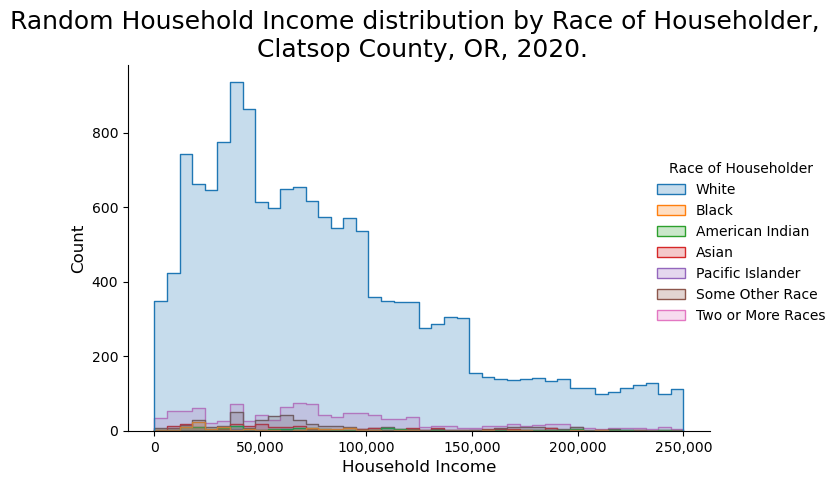

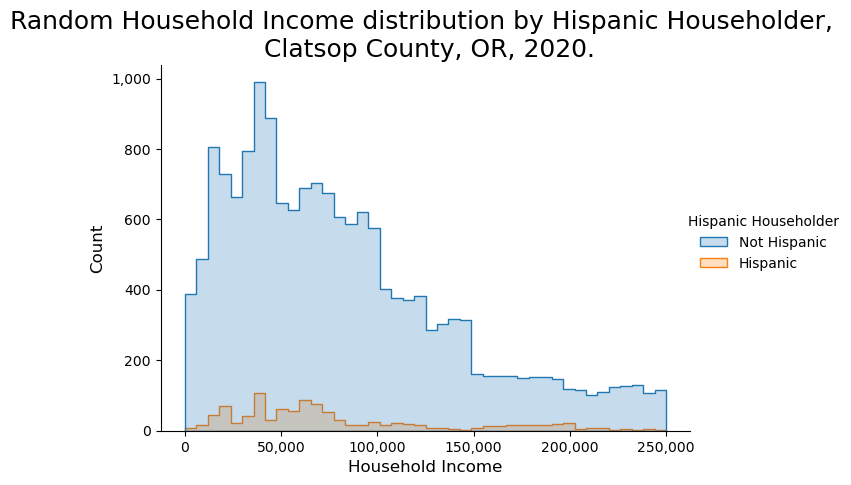

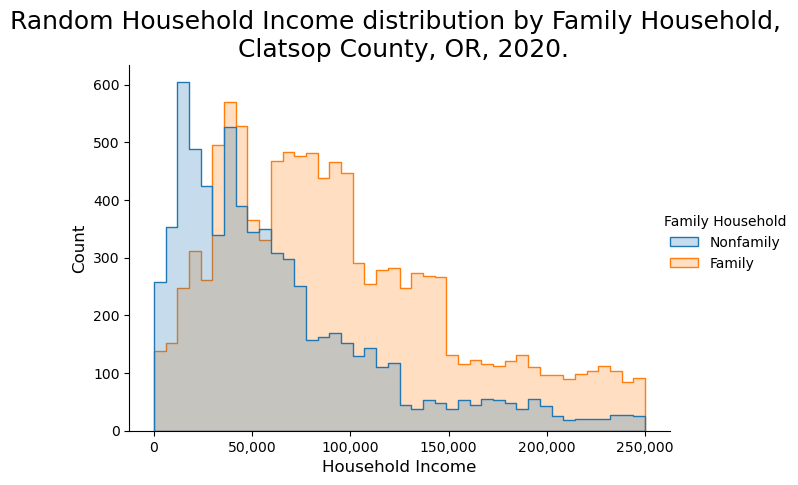

In [8]:
work_dir = Path.cwd() / "pyncoda_working_dir"

PyncodaHousingUnitAllocator(
    inventory=bldg_inventory_imputed,
    vintage='2020',
    seed=9878,
    key_features=dict(
        occupancy_col="OccupancyClass",
        plan_area_col="PlanArea",
        story_count_col="NumberOfStories",
        length_unit="ft",
    ),
    work_dir=str(work_dir),
    clean_work_dir=True
).allocate()

## 7. Export Results

Finally, we save our work to local files:
- **`bldg_inventory.geojson`**: The physical building inventory. Buildings with
  assigned households will contain a `HousingUnits` field with a list of IDs.
- **`housing_units.json`**: The demographic inventory. This file contains detailed
  attributes (e.g., `Ownership`, `Race`, `IncomeGroup`) for every household ID.

These two files are linked relationally by these IDs.

In [9]:
# Buildings
bldg_inventory_imputed.write_to_geojson('bldg_inventory.geojson')

# Housing Units
bldg_inventory_imputed.housing_unit_inventory.to_json('housing_units.json')

Wrote 4679 assets to c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\bldg_inventory.geojson


{'type': 'HousingUnitInventory',
 'generated': '2025-12-03 18:10:40.486241+00:00',
 'brails_version': '4.2.0',
 'housing_units': {'42': {'BLOCK_GEOID': '410079507001012',
   'NumberOfPersons': 1,
   'Ownership': 'Owner occupied',
   'Race': 'White',
   'Hispanic': 0.0,
   'Family': 0.0,
   'VacancyStatus': 'Occupied',
   'GroupQuartersType': 'Not a group quarters building',
   'IncomeGroup': '$60,000 to $74,999',
   'IncomeSample': 64545.0,
   'Poverty': 0.0},
  '43': {'BLOCK_GEOID': '410079507001012',
   'NumberOfPersons': 1,
   'Ownership': 'Owner occupied',
   'Race': 'White',
   'Hispanic': 0.0,
   'Family': 0.0,
   'VacancyStatus': 'Occupied',
   'GroupQuartersType': 'Not a group quarters building',
   'IncomeGroup': '$60,000 to $74,999',
   'IncomeSample': 62482.0,
   'Poverty': 0.0},
  '44': {'BLOCK_GEOID': '410079507001012',
   'NumberOfPersons': 1,
   'Ownership': 'Owner occupied',
   'Race': 'White',
   'Hispanic': 0.0,
   'Family': 0.0,
   'VacancyStatus': 'Occupied',
   'Gr